In [ ]:
!pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

random.seed(42)
np.random.seed(42)
print("Ready!")

Ready!


Generate Weekly Demand Data

In [ ]:
# Simulate 2 years of weekly procurement demand (units ordered)
weeks = pd.date_range(start='2022-01-01', end='2023-12-31', freq='W')

# Realistic demand: upward trend + seasonality + noise
trend      = np.linspace(200, 320, len(weeks))
seasonality = 40 * np.sin(2 * np.pi * np.arange(len(weeks)) / 52)  # yearly cycle
noise       = np.random.normal(0, 20, len(weeks))
demand      = trend + seasonality + noise
demand      = np.clip(demand, 50, None)   # no negative demand

df = pd.DataFrame({
    'ds': weeks,          # Prophet needs column named 'ds'
    'y' : demand          # Prophet needs column named 'y'
})

print(f" {len(df)} weeks of demand data generated")
print(f"Avg weekly demand : {df['y'].mean():.1f} units")
print(f"Min → Max         : {df['y'].min():.1f} → {df['y'].max():.1f} units")
df.head(10)

 105 weeks of demand data generated
Avg weekly demand : 257.4 units
Min → Max         : 164.7 → 342.6 units


,ds,y
0,2022-01-02,209.934283
1,2022-01-09,203.210027
2,2022-01-16,224.834090
3,2022-01-23,248.106331
4,2022-01-30,218.521244
5,2022-02-06,223.809081
6,2022-02-13,265.032240
7,2022-02-20,253.366048
8,2022-02-27,232.760636
9,2022-03-06,256.654057


Plot Raw Demand

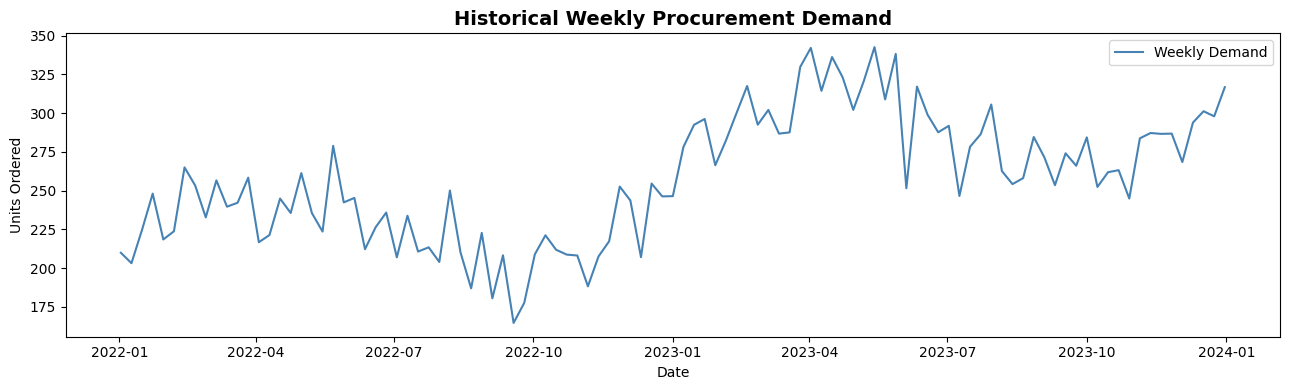

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['ds'], df['y'], color='steelblue', linewidth=1.5, label='Weekly Demand')
ax.set_title('Historical Weekly Procurement Demand', fontsize=14, fontweight='bold')
ax.set_ylabel('Units Ordered')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

Train Prophet Model

In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,   # controls trend flexibility
    interval_width=0.95             # 95% confidence interval
)

model.fit(df)
print("Prophet model trained!")

Prophet model trained!


Forecast Next 12 Weeks

In [ ]:
# Create future dataframe — 12 weeks ahead
future   = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

# Show forecast columns
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(15)

,ds,yhat,yhat_lower,yhat_upper
102,2023-12-17,294.190795,264.404093,324.719773
103,2023-12-24,305.128876,274.406977,336.945599
104,2023-12-31,321.452153,290.425152,354.577246
105,2024-01-07,337.418605,305.262641,368.326313
106,2024-01-14,347.789651,316.230805,380.821538
107,2024-01-21,351.455998,319.544539,382.570211
108,2024-01-28,352.208144,319.904288,384.448468
109,2024-02-04,355.437553,324.366563,385.518459
110,2024-02-11,362.967459,333.067901,391.971915
111,2024-02-18,370.884526,339.875085,401.989876


Plot Forecast

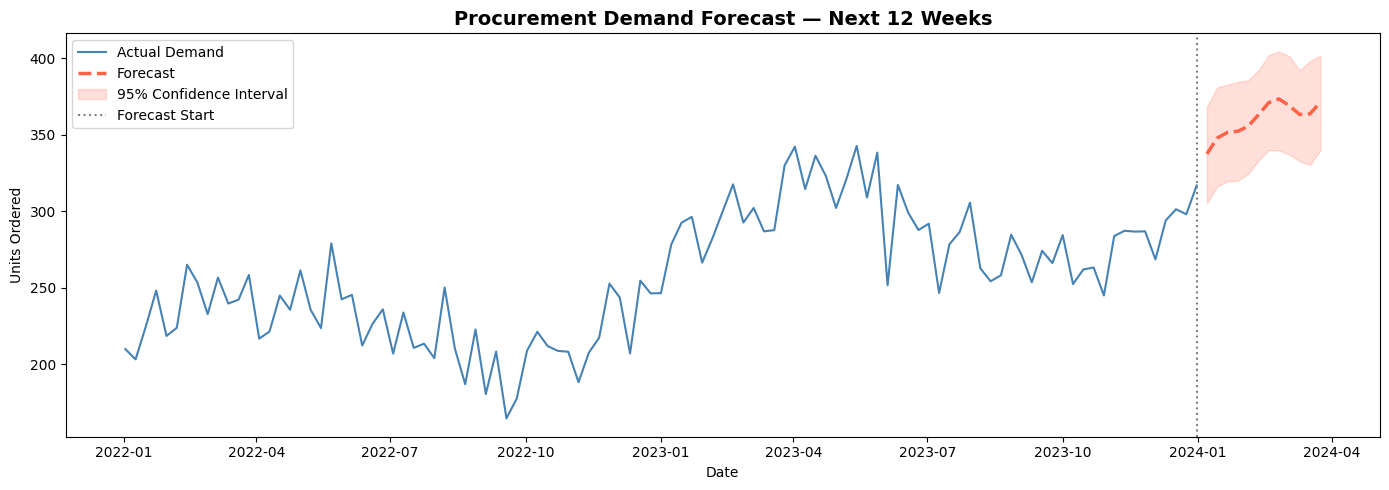

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# Historical
ax.plot(df['ds'], df['y'], color='steelblue', linewidth=1.5, label='Actual Demand')

# Forecast
future_only = forecast[forecast['ds'] > df['ds'].max()]
ax.plot(future_only['ds'], future_only['yhat'],
        color='tomato', linewidth=2.5, linestyle='--', label='Forecast')

# Confidence interval
ax.fill_between(future_only['ds'],
                future_only['yhat_lower'],
                future_only['yhat_upper'],
                alpha=0.2, color='tomato', label='95% Confidence Interval')

# Divider line
ax.axvline(df['ds'].max(), color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')

ax.set_title('Procurement Demand Forecast — Next 12 Weeks', fontsize=14, fontweight='bold')
ax.set_ylabel('Units Ordered')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

 Plot Trend & Seasonality Components

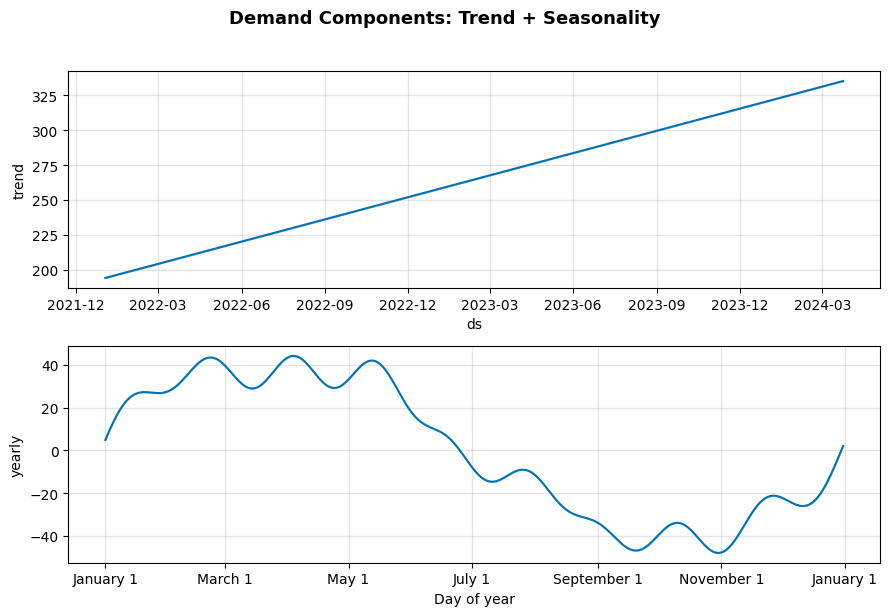

In [ ]:
# This is Prophet's built-in decomposition — very powerful!
fig = model.plot_components(forecast)
plt.suptitle('Demand Components: Trend + Seasonality',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Business Insights

In [ ]:
future_only = forecast[forecast['ds'] > df['ds'].max()].copy()
future_only['week'] = future_only['ds'].dt.strftime('%Y-%m-%d')

print("=" * 55)
print("     DEMAND FORECAST — NEXT 12 WEEKS")
print("=" * 55)
print(f"\n{'Week':<15} {'Forecast':>10} {'Low':>10} {'High':>10}")
print("-" * 50)
for _, row in future_only.iterrows():
    print(f"{row['week']:<15} {row['yhat']:>10.0f} "
          f"{row['yhat_lower']:>10.0f} {row['yhat_upper']:>10.0f}")

total_forecast = future_only['yhat'].sum()
avg_weekly     = future_only['yhat'].mean()
print(f"\n Total forecasted demand (12 weeks) : {total_forecast:.0f} units")
print(f" Average weekly demand               : {avg_weekly:.0f} units")
print(f" Suggested safety stock (10% buffer) : {total_forecast * 0.10:.0f} units")

     DEMAND FORECAST — NEXT 12 WEEKS

Week              Forecast        Low       High
--------------------------------------------------
2024-01-07             337        305        368
2024-01-14             348        316        381
2024-01-21             351        320        383
2024-01-28             352        320        384
2024-02-04             355        324        386
2024-02-11             363        333        392
2024-02-18             371        340        402
2024-02-25             373        340        404
2024-03-03             369        337        401
2024-03-10             363        333        392
2024-03-17             364        330        398
2024-03-24             371        340        402

 Total forecasted demand (12 weeks) : 4318 units
 Average weekly demand               : 360 units
 Suggested safety stock (10% buffer) : 432 units
